Matplotlib is building the font cache; this may take a moment.


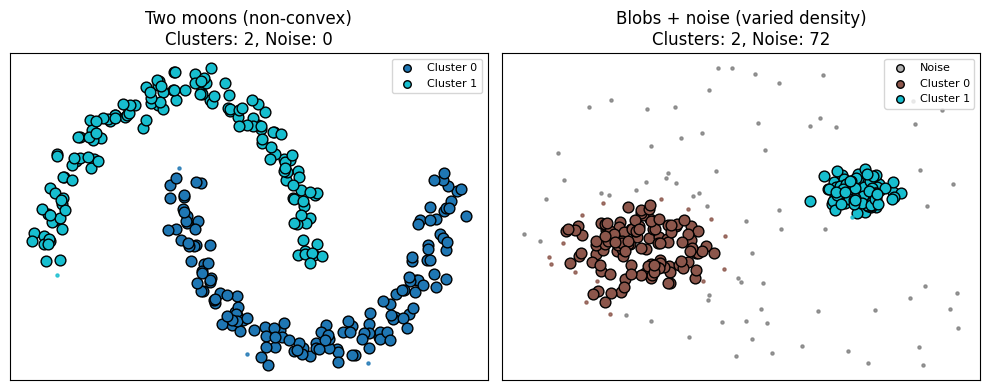

In [1]:
import numpy as np
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# DBSCAN demo for a Jupyter cell (index 0)
import matplotlib.pyplot as plt

# Create datasets: non-convex (moons) and varied density (blobs + noise)
rng = np.random.RandomState(42)
X1, _ = make_moons(n_samples=300, noise=0.06, random_state=rng)
X2, _ = make_blobs(n_samples=300, centers=[[1.5, 0.5], [-1.5, -0.5]], cluster_std=[0.2, 0.6], random_state=rng)
noise = rng.uniform(low=-3, high=3, size=(60, 2))
X_varied = np.vstack([X2, noise])

datasets = [("Two moons (non-convex)", X1), ("Blobs + noise (varied density)", X_varied)]

plt.figure(figsize=(10, 4))
for i, (title, X) in enumerate(datasets, 1):
    X_scaled = StandardScaler().fit_transform(X)
    db = DBSCAN(eps=0.25, min_samples=5).fit(X_scaled)
    labels = db.labels_
    core_mask = np.zeros_like(labels, dtype=bool)
    if hasattr(db, "core_sample_indices_") and db.core_sample_indices_ is not None:
        core_mask[db.core_sample_indices_] = True

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    ax = plt.subplot(1, 2, i)
    unique_labels = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(unique_labels))))
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = (0.5, 0.5, 0.5, 0.6)  # noise grey
        class_member_mask = (labels == k)
        xy = X_scaled[class_member_mask & core_mask]
        ax.scatter(xy[:, 0], xy[:, 1], s=60, c=[col], marker="o", edgecolor="k", label=f"Cluster {k}" if k != -1 else "Noise")
        xy = X_scaled[class_member_mask & ~core_mask]
        ax.scatter(xy[:, 0], xy[:, 1], s=20, c=[col], marker=".", alpha=0.8)

    ax.set_title(f"{title}\nClusters: {n_clusters}, Noise: {n_noise}")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="upper right", markerscale=0.7, fontsize=8)

plt.tight_layout()
plt.show()